# JMAIL Pipeline Processing

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import dotenv_values

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

ENV_PATH = PROJECT_ROOT / ".env"
ENV = dotenv_values(ENV_PATH)


def _resolve(key, default):
    v = ENV.get(key, default)
    p = Path(v)
    return p if p.is_absolute() else PROJECT_ROOT / p


SAMPLE_SIZE = int(ENV.get("PROCESSING_SAMPLE_SIZE", "1000"))

RAW_SAMPLE_PATH = _resolve("DATA_RAW_PATH", "data/raw/") / ENV.get(
    "RAW_EMAILS_SAMPLE_FILENAME", "jmail_emails_sample.parquet"
)
PROCESSED_SAMPLE_PATH = _resolve("DATA_PROCESSED_PATH", "data/processed/") / ENV.get(
    "PROCESSED_EMAILS_SAMPLE_FILENAME", "jmail_emails_processed_sample.parquet"
)
RAW_PROFILING_PATH = _resolve("METADATA_PATH", "data/metadata/") / "profiling/raw/profile.json"
PROCESSED_PROFILING_PATH = _resolve("METADATA_PATH", "data/metadata/") / "profiling/processed/profile.json"

plt.style.use("default")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 200)

# Sample Raw

In [2]:
from src.utils.data_extraction import run_extraction

extraction_result = run_extraction(env_file=str(ENV_PATH), sample_limit=SAMPLE_SIZE)
extraction_result

{'endpoint': 'v1/emails.parquet',
 'raw_output_path': 'data/raw/jmail_emails.parquet',
 'metadata_output_path': 'data/metadata/jmail_extraction_metadata.json',
 'sample_output_path': 'data/raw/jmail_emails_sample.parquet',
 'row_count': 1783792,
 'column_count': 19}

In [3]:
from src.utils.data_profiling import profile_parquet, write_profile

raw_profile = profile_parquet(RAW_SAMPLE_PATH)
write_profile(raw_profile, RAW_PROFILING_PATH)

print(f"Shape: {raw_profile['row_count']} rows × {raw_profile['column_count']} columns")

Shape: 1000 rows × 19 columns


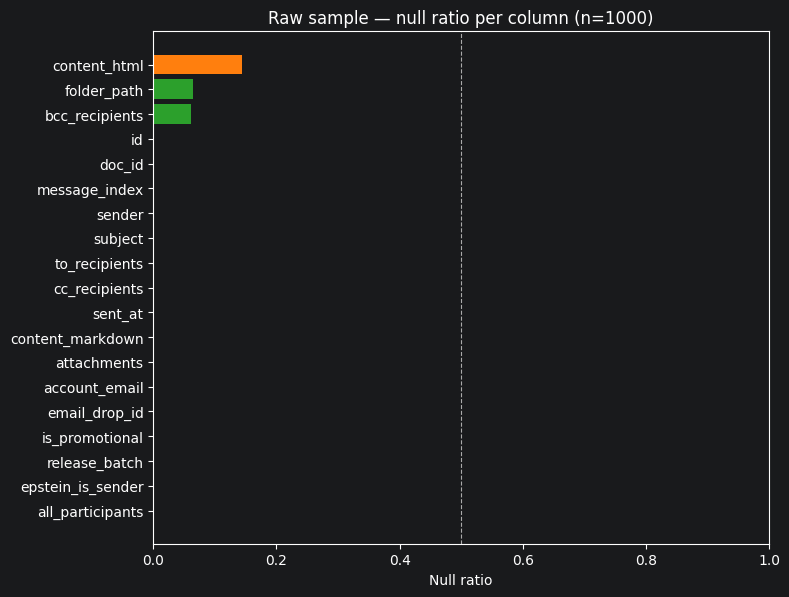

In [4]:
cols_data = sorted(
    [(c["name"], c["null_ratio"] or 0) for c in raw_profile["columns"]],
    key=lambda x: x[1],
    reverse=True,
)
names, ratios = zip(*cols_data)

fig, ax = plt.subplots(figsize=(8, max(4, len(names) * 0.32)))
colors = ["#d62728" if r > 0.5 else "#ff7f0e" if r > 0.1 else "#2ca02c" for r in ratios]
ax.barh(names, ratios, color=colors)
ax.set_xlabel("Null ratio")
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.axvline(0.5, color="#aaa", linestyle="--", linewidth=0.8)
ax.set_title(f"Raw sample — null ratio per column (n={raw_profile['row_count']})")
plt.tight_layout()
plt.show()

# Processing

In [5]:
from src.utils.data_processing import run_processing_with_limit

processing_result = run_processing_with_limit(env_file=str(ENV_PATH), limit=SAMPLE_SIZE)
processing_result

{'raw_path': '/home/suga/Workspace/Projects/pizza-cluster/data/raw/jmail_emails.parquet',
 'processed_output_path': '/home/suga/Workspace/Projects/pizza-cluster/data/processed/jmail_emails_processed_sample.parquet',
 'metadata_output_path': '/home/suga/Workspace/Projects/pizza-cluster/data/metadata/jmail_processing_sample_metadata.json',
 'input_rows': 1000,
 'output_rows': 355,
 'removed_promotional_rows': 645,
 'removed_empty_text_rows': 0}

In [6]:
processed_profile = profile_parquet(PROCESSED_SAMPLE_PATH)
processed_profile["raw_source_path"] = str(RAW_SAMPLE_PATH)
write_profile(processed_profile, PROCESSED_PROFILING_PATH)

print(f"Shape: {processed_profile['row_count']} rows × {processed_profile['column_count']} columns")

Shape: 355 rows × 30 columns


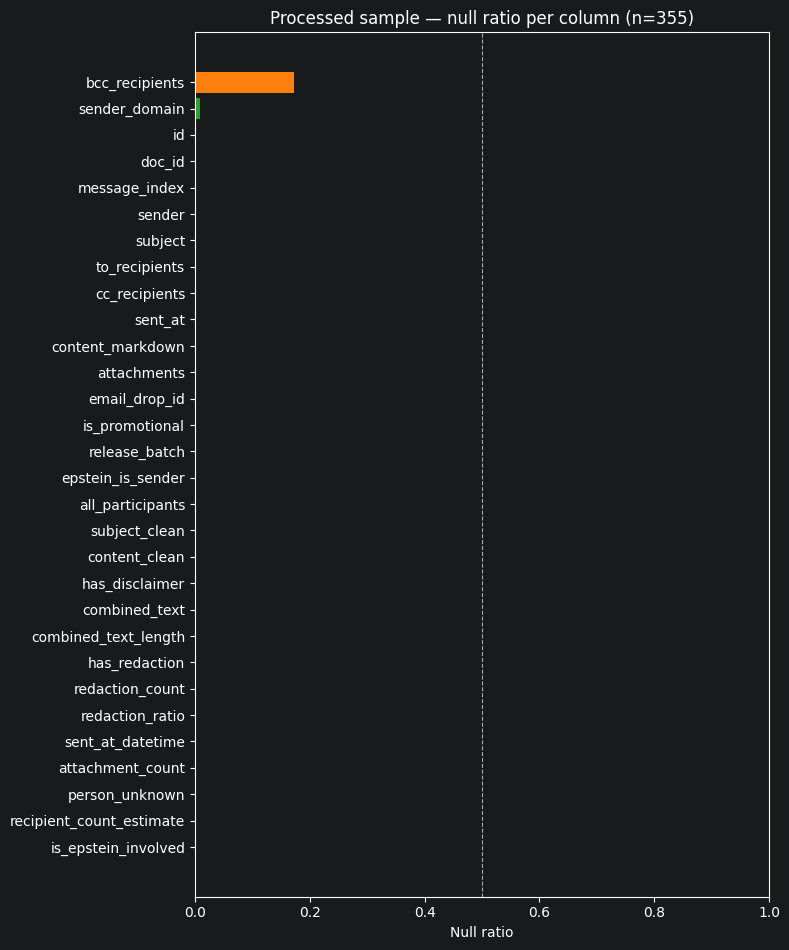

In [7]:
cols_data = sorted(
    [(c["name"], c["null_ratio"] or 0) for c in processed_profile["columns"]],
    key=lambda x: x[1],
    reverse=True,
)
names, ratios = zip(*cols_data)

fig, ax = plt.subplots(figsize=(8, max(4, len(names) * 0.32)))
colors = ["#d62728" if r > 0.5 else "#ff7f0e" if r > 0.1 else "#2ca02c" for r in ratios]
ax.barh(names, ratios, color=colors)
ax.set_xlabel("Null ratio")
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.axvline(0.5, color="#aaa", linestyle="--", linewidth=0.8)
ax.set_title(f"Processed sample — null ratio per column (n={processed_profile['row_count']})")
plt.tight_layout()
plt.show()

# Comparison

In [8]:
raw_df = pd.read_parquet(RAW_SAMPLE_PATH)
processed_df = pd.read_parquet(PROCESSED_SAMPLE_PATH)

rows_in = raw_profile["row_count"]
rows_out = processed_profile["row_count"]
rows_removed = rows_in - rows_out

summary = pd.DataFrame([
    {"dataset": "raw", "rows": rows_in, "columns": raw_profile["column_count"]},
    {"dataset": "processed", "rows": rows_out, "columns": processed_profile["column_count"]},
])
display(summary)
print(f"\nRows removed: {rows_removed} ({rows_removed / rows_in * 100:.1f}%)")

added_cols = sorted(set(processed_df.columns) - set(raw_df.columns))
removed_cols = sorted(set(raw_df.columns) - set(processed_df.columns))
if added_cols:
    print(f"Columns added:   {added_cols}")
if removed_cols:
    print(f"Columns removed: {removed_cols}")

,dataset,rows,columns
0,raw,1000,19
1,processed,355,30



Rows removed: 645 (64.5%)
Columns added:   ['attachment_count', 'combined_text', 'combined_text_length', 'content_clean', 'has_disclaimer', 'has_redaction', 'is_epstein_involved', 'person_unknown', 'recipient_count_estimate', 'redaction_count', 'redaction_ratio', 'sender_domain', 'sent_at_datetime', 'subject_clean']
Columns removed: ['account_email', 'content_html', 'folder_path']


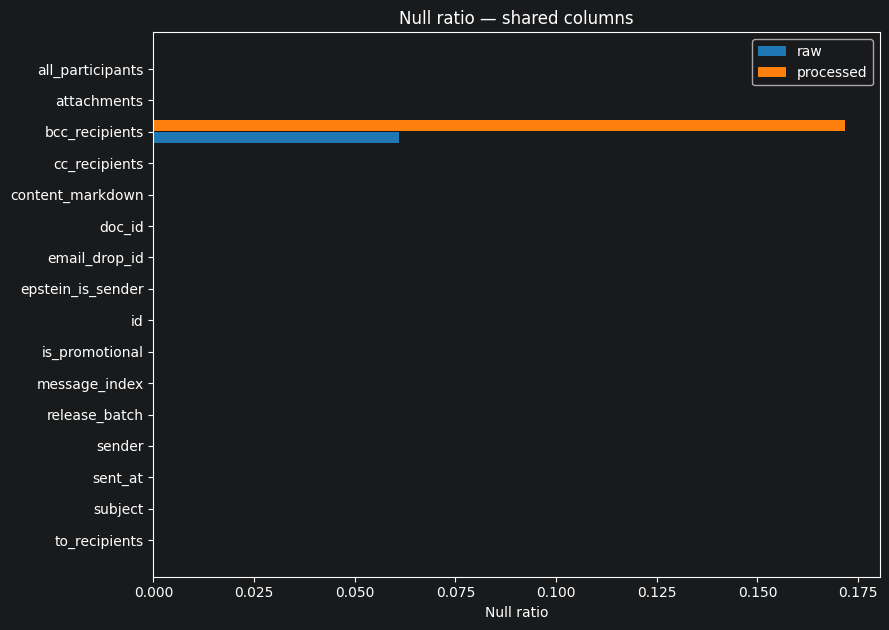

In [9]:
raw_nulls = {c["name"]: c["null_ratio"] or 0 for c in raw_profile["columns"]}
proc_nulls = {c["name"]: c["null_ratio"] or 0 for c in processed_profile["columns"]}
shared = sorted(set(raw_nulls) & set(proc_nulls))

y = range(len(shared))
fig, ax = plt.subplots(figsize=(9, max(4, len(shared) * 0.4)))
ax.barh([i + 0.2 for i in y], [raw_nulls[c] for c in shared], height=0.35, label="raw", color="#1f77b4")
ax.barh([i - 0.2 for i in y], [proc_nulls[c] for c in shared], height=0.35, label="processed", color="#ff7f0e")
ax.set_yticks(list(y))
ax.set_yticklabels(shared)
ax.set_xlabel("Null ratio")
ax.invert_yaxis()
ax.legend()
ax.set_title("Null ratio — shared columns")
plt.tight_layout()
plt.show()

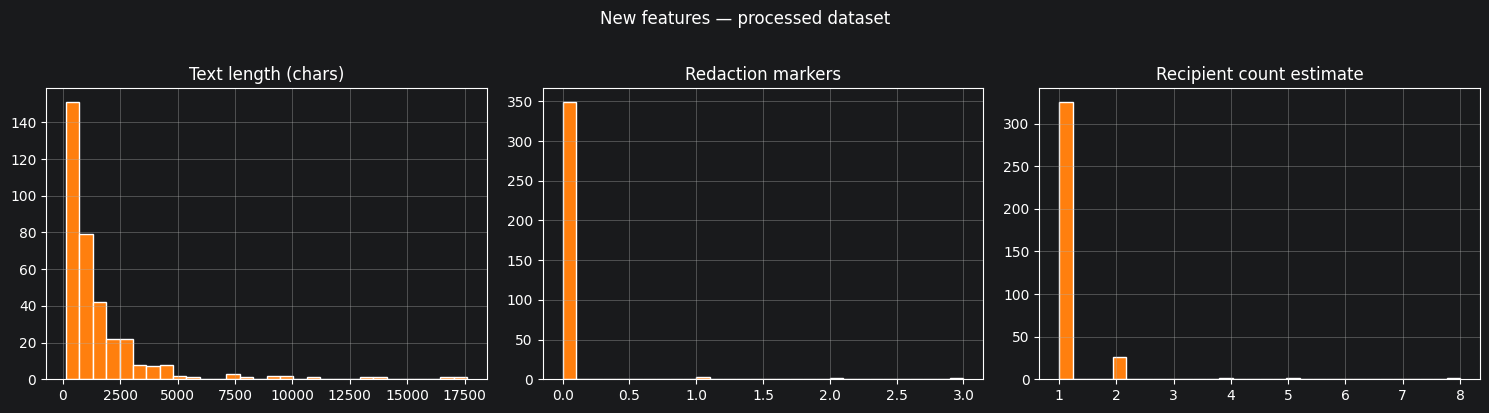

In [10]:
feature_cols = [
    ("combined_text_length", "Text length (chars)"),
    ("redaction_count", "Redaction markers"),
    ("recipient_count_estimate", "Recipient count estimate"),
]
available = [(col, label) for col, label in feature_cols if col in processed_df.columns]

fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 4))
if len(available) == 1:
    axes = [axes]

for ax, (col, label) in zip(axes, available):
    processed_df[col].dropna().astype(float).hist(bins=30, ax=ax, color="#ff7f0e", edgecolor="white")
    ax.set_title(label)

plt.suptitle("New features — processed dataset", y=1.02)
plt.tight_layout()
plt.show()

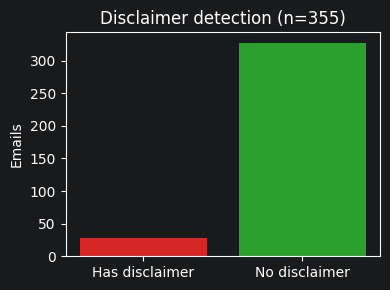

In [11]:
if "has_disclaimer" in processed_df.columns:
    counts = processed_df["has_disclaimer"].value_counts().reindex([True, False], fill_value=0)
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.bar(["Has disclaimer", "No disclaimer"], [counts[True], counts[False]], color=["#d62728", "#2ca02c"])
    ax.set_ylabel("Emails")
    ax.set_title(f"Disclaimer detection (n={len(processed_df)})")
    plt.tight_layout()
    plt.show()

Struttura del `combined_text` dopo l'applicazione del template di embedding.

In [14]:
for i, row in processed_df[["combined_text"]].head(3).iterrows():
    print(f"=== Row {i} ===")
    print(row["combined_text"][:400])
    print()

=== Row 0 ===
DATE: 2015-05-07T07:07:33.000Z
FROM: jeffrey E.  <jeevacation@gmail.com>
TO: ["Ehud Barak  <ehbarak1@gmail.com>"]
SUBJECT: Re: Title and subtitle

BODY:
prefer OUR COUNTRY , MY LIFE or MOMENTS

=== Row 1 ===
DATE: 2006-07-10T18:13:50.000Z
FROM: J. Epstein <jeeproject@yahoo.com>
TO: ["Cecilia Steen <cecilia.steen@gmail.com>"]
SUBJECT: Re: Barbro Ehnbom: SALSS 2006

BODY:
i'll try --- Cecilia Steen <cecilia.steen@gmail.com> wrote: > Dear Jeffrey, > > It would be great if you could come over for this > summit in Stockholm August > 16 - 18th. You will meet some of the best scientific > minds in Sweden, we

=== Row 2 ===
DATE: 2007-02-19T20:50:39.000Z
FROM: J. Epstein <jeeproject@yahoo.com>
TO: ["<gmax1@mindspring.com>"]
SUBJECT: Re:

BODY:
both ----- Original Message ---- From: Gmax <gmax1@mindspring.com> To: "Epstein, Jeffrey" <jeeproject@yahoo.com> Sent: Sunday, February 18, 2007 11:47:11 PM Subject: When to the Radar site - was it to see yucky pic of Flavio or article on w